# Comprehensive Exploratory Data Analysis

---

## Executive Summary

This notebook presents a structured exploratory data analysis (EDA) of the  dataset, containing **16,209 residential property transactions**. The analysis focuses on understanding price drivers, identifying key predictive features, and generating actionable insights for predictive modeling.

### Dataset Overview

The housing dataset includes sales from houses. Each record represents a completed house sale with comprehensive property characteristics.

---

## Data Dictionary

Given dataset contains the prices of houses sold. Here is the description of each column:

| Feature | Description | Type |
|---------|-------------|------|
| **id** | Unique ID for each home sold | Identifier |
| **date** | Date of the home sale | Temporal |
| **price** | Price of each home sold **(Target Variable)** | Continuous |
| **bedrooms** | Number of bedrooms | Discrete |
| **bathrooms** | Number of bathrooms (0.5 = powder room) | Continuous |
| **sqft_living** | Interior living space square footage | Continuous |
| **sqft_lot** | Land space square footage | Continuous |
| **floors** | Number of floors | Discrete |
| **waterfront** | Waterfront property indicator (0/1) | Binary |
| **view** | View quality index (0-4) | Ordinal |
| **condition** | Overall condition index (1-5) | Ordinal |
| **grade** | Construction quality index (1-13) | Ordinal |
| **sqft_above** | Above-ground interior square footage | Continuous |
| **sqft_basement** | Basement square footage | Continuous |
| **yr_built** | Year house was built | Temporal |
| **yr_renovated** | Year of last renovation (0 if never) | Temporal |
| **zipcode** | ZIP code area | Categorical |
| **lat** | Latitude coordinate | Geospatial |
| **long** | Longitude coordinate | Geospatial |
| **sqft_living15** | Living space of nearest 15 neighbors | Continuous |
| **sqft_lot15** | Lot size of nearest 15 neighbors | Continuous |

---

## 1. Importing the libraries


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import rasterio

## 2. Data Loading and Initial Exploration


In [5]:
df = pd.read_csv('/content/drive/MyDrive/CDC_House/train.csv')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16204,5272200045,20141113T000000,378000,3,1.50,1000,6914,1.0,0,0,...,7,1000,0,1947,0,98125,47.7144,-122.319,1000,6947
16205,9578500790,20141111T000000,399950,3,2.50,3087,5002,2.0,0,0,...,8,3087,0,2014,0,98023,47.2974,-122.349,2927,5183
16206,7202350480,20140930T000000,575000,3,2.50,2120,4780,2.0,0,0,...,7,2120,0,2004,0,98053,47.6810,-122.032,1690,2650
16207,1723049033,20140620T000000,245000,1,0.75,380,15000,1.0,0,0,...,5,380,0,1963,0,98168,47.4810,-122.323,1170,15000


In [6]:
df['year']=df['date'].str[:4].astype(int)
df['month'] = df['date'].str[4:6].astype(int)
df.drop(columns='date', axis=1, inplace=True)

In [7]:
df

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
0,9117000170,268643,4,2.25,1810,9240,2.0,0,0,3,...,0,1961,0,98055,47.4362,-122.187,1660,9240,2015,5
1,6700390210,245000,3,2.50,1600,2788,2.0,0,0,4,...,0,1992,0,98031,47.4034,-122.187,1720,3605,2014,7
2,7212660540,200000,4,2.50,1720,8638,2.0,0,0,3,...,0,1994,0,98003,47.2704,-122.313,1870,7455,2015,1
3,8562780200,352499,2,2.25,1240,705,2.0,0,0,3,...,90,2009,0,98027,47.5321,-122.073,1240,750,2015,4
4,7760400350,232000,3,2.00,1280,13356,1.0,0,0,3,...,0,1994,0,98042,47.3715,-122.074,1590,8071,2014,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16204,5272200045,378000,3,1.50,1000,6914,1.0,0,0,3,...,0,1947,0,98125,47.7144,-122.319,1000,6947,2014,11
16205,9578500790,399950,3,2.50,3087,5002,2.0,0,0,3,...,0,2014,0,98023,47.2974,-122.349,2927,5183,2014,11
16206,7202350480,575000,3,2.50,2120,4780,2.0,0,0,3,...,0,2004,0,98053,47.6810,-122.032,1690,2650,2014,9
16207,1723049033,245000,1,0.75,380,15000,1.0,0,0,3,...,0,1963,0,98168,47.4810,-122.323,1170,15000,2014,6


In [8]:
df.describe().T.style.bar(
    subset=['mean'],
    color='#606ff2').background_gradient(
    subset=['std'], cmap='PuBu').background_gradient(subset=['50%'], cmap='PuBu')

,count,mean,std,min,25%,50%,75%,max
id,16209.000000,4575770827.163366,2874661405.393437,1000102.000000,2123049194.000000,3904950190.000000,7304301005.000000,9900000190.000000
price,16209.000000,537470.282744,360303.577357,75000.000000,320000.000000,450000.000000,640000.000000,7700000.000000
bedrooms,16209.000000,3.367820,0.933270,0.000000,3.000000,3.000000,4.000000,33.000000
bathrooms,16209.000000,2.113054,0.765242,0.000000,1.500000,2.250000,2.500000,8.000000
sqft_living,16209.000000,2073.274601,907.009491,290.000000,1430.000000,1910.000000,2550.000000,12050.000000
sqft_lot,16209.000000,14867.673145,38825.702074,520.000000,5004.000000,7599.000000,10631.000000,1164794.000000
floors,16209.000000,1.498828,0.543032,1.000000,1.000000,1.500000,2.000000,3.500000
waterfront,16209.000000,0.006971,0.083206,0.000000,0.000000,0.000000,0.000000,1.000000
view,16209.000000,0.234253,0.763152,0.000000,0.000000,0.000000,0.000000,4.000000
condition,16209.000000,3.407860,0.651553,1.000000,3.000000,3.000000,4.000000,5.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             16209 non-null  int64  
 1   price          16209 non-null  int64  
 2   bedrooms       16209 non-null  int64  
 3   bathrooms      16209 non-null  float64
 4   sqft_living    16209 non-null  int64  
 5   sqft_lot       16209 non-null  int64  
 6   floors         16209 non-null  float64
 7   waterfront     16209 non-null  int64  
 8   view           16209 non-null  int64  
 9   condition      16209 non-null  int64  
 10  grade          16209 non-null  int64  
 11  sqft_above     16209 non-null  int64  
 12  sqft_basement  16209 non-null  int64  
 13  yr_built       16209 non-null  int64  
 14  yr_renovated   16209 non-null  int64  
 15  zipcode        16209 non-null  int64  
 16  lat            16209 non-null  float64
 17  long           16209 non-null  float64
 18  sqft_l

In [10]:
df[df.duplicated()]

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month


No duplicate data found

In [11]:
df[df.duplicated('id', keep=False)].sort_values('id')

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
8650,123039336,148000,1,1.00,620,8261,1.0,0,0,3,...,0,1939,0,98106,47.5138,-122.364,1180,8244,2014,6
14950,123039336,244900,1,1.00,620,8261,1.0,0,0,3,...,0,1939,0,98106,47.5138,-122.364,1180,8244,2014,12
14554,526059224,470000,4,1.75,1650,7276,1.0,0,0,3,...,640,1977,0,98011,47.7721,-122.206,1840,8550,2015,2
1222,526059224,260000,4,1.75,1650,7276,1.0,0,0,3,...,640,1977,0,98011,47.7721,-122.206,1840,8550,2014,9
1890,643300040,481000,4,1.75,1920,9500,1.0,0,0,4,...,450,1966,0,98006,47.5683,-122.177,1820,10091,2014,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14090,9407110710,322000,3,1.75,1510,8400,1.0,0,0,2,...,530,1979,0,98045,47.4476,-121.771,1500,10125,2015,2
11594,9809000020,1895000,5,2.25,3120,16672,2.0,0,0,4,...,0,1969,0,98004,47.6458,-122.219,3740,17853,2014,5
4817,9809000020,1940000,5,2.25,3120,16672,2.0,0,0,4,...,0,1969,0,98004,47.6458,-122.219,3740,17853,2015,3
9222,9834200305,350000,3,1.00,1790,3876,1.5,0,0,5,...,700,1904,0,98144,47.5750,-122.288,1360,4080,2014,7


This implies that there are 99 houses which are sold twice. This dataset has only two differentiating factor i.e. year and month.

## 3. Visualizations and Statistical Analysis

In this section, we systematically explore the dataset through visualizations, examining distributions, relationships, and patterns that inform our modeling strategy.

---


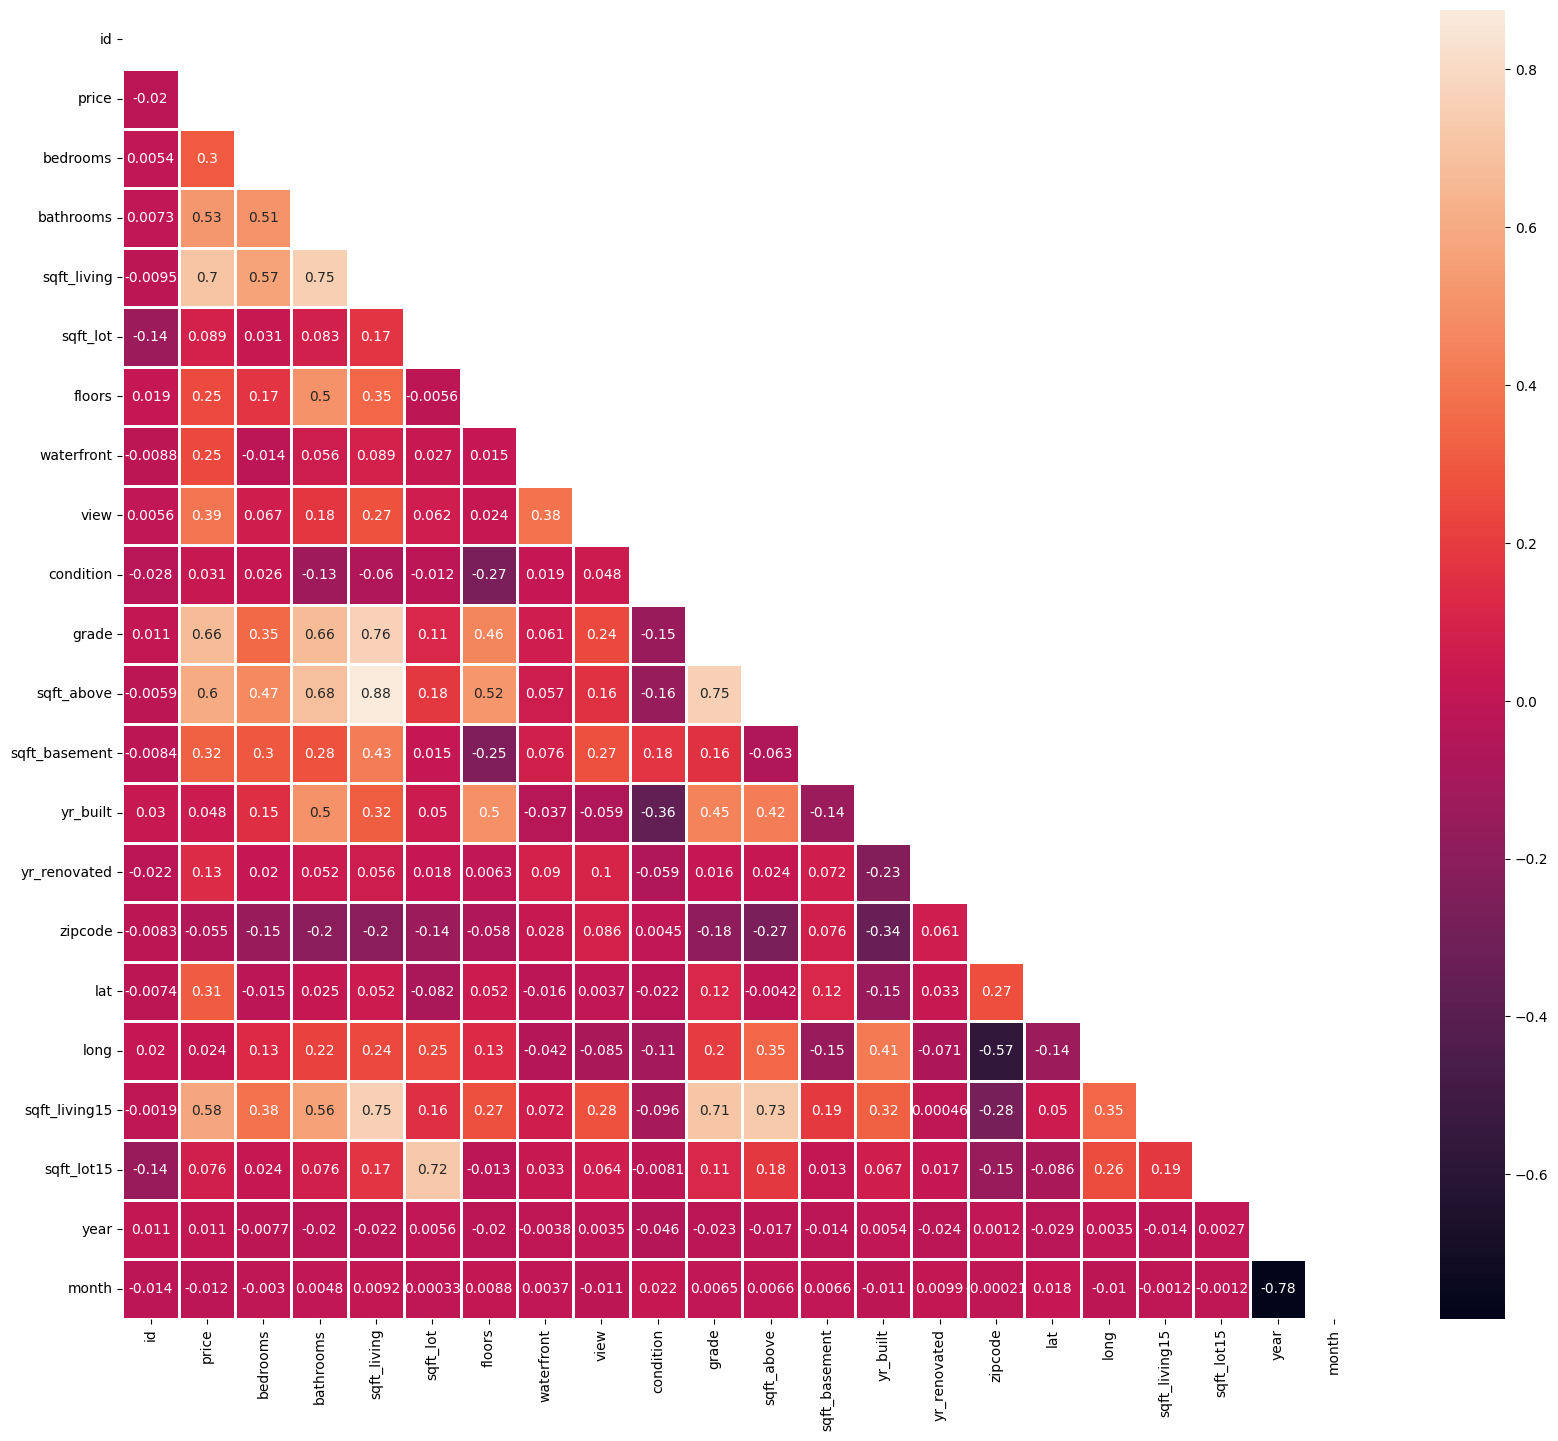

In [12]:
plt.figure(figsize=(20, 17))
matrix = np.triu(df.corr())
sns.heatmap(df.corr(), annot=True,
            linewidth=1, mask=matrix, cmap="rocket");

### 📊 Interpretation

**Key Findings from Correlation Analysis:**

- The top 5 correlates with house price are:
  - **sqft_living**: r = 0.701 (strongest positive association)
  - **grade**: r = 0.664
  - **sqft_above**: r = 0.603
  - **sqft_living15**: r = 0.582
  - **bathrooms**: r = 0.525

- **Multicollinearity Alert**: `sqft_living` correlates strongly with `sqft_above` (r ≈ 0.88), suggesting potential redundancy.

- **Location Matters**: Geographic features (`lat`, `long`) show moderate correlations with price, indicating spatial heterogeneity in the housing market.

---


Generating Frequency Plots: 100%|██████████| 20/20 [00:00<00:00, 36.16it/s]


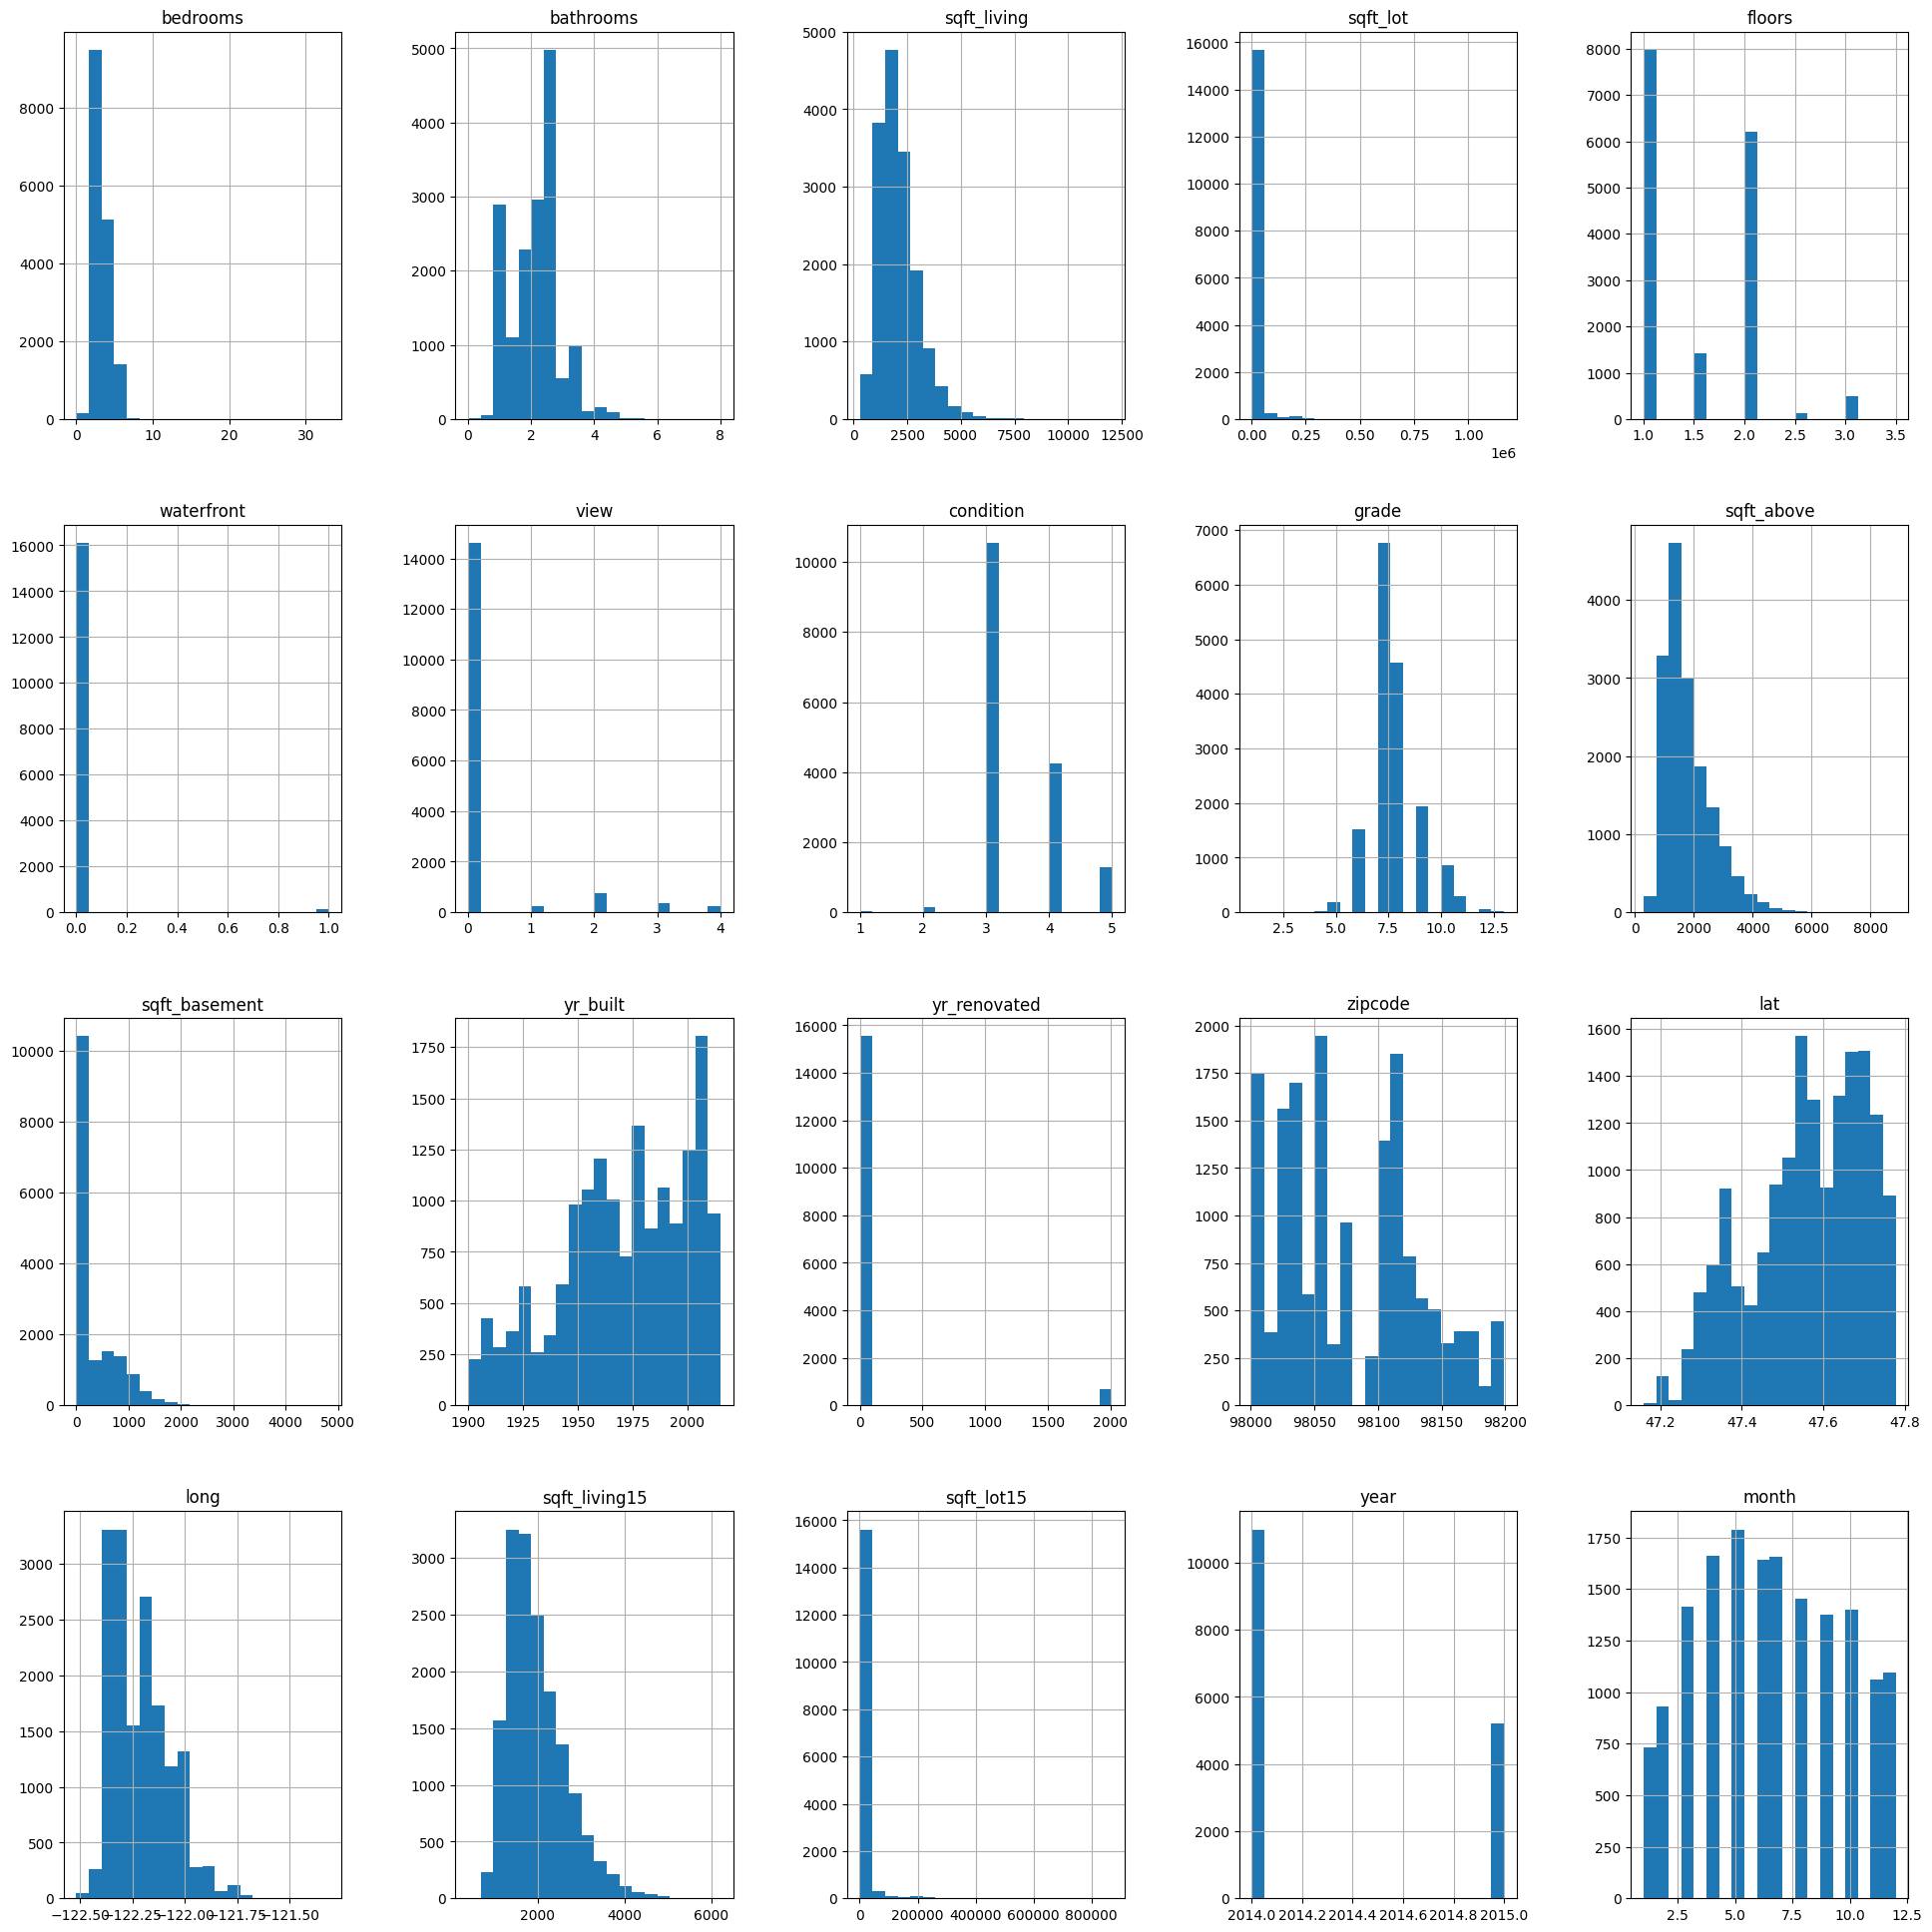

In [13]:
plot_data = df.drop(['id', 'price'], axis=1)

fig = plt.figure(figsize=(20, 20))
cols = plot_data.columns
rows = int(np.ceil(len(cols) / 5))

for i in tqdm(range(len(cols)), desc='Generating Frequency Plots'):
    fig.add_subplot(rows, 5, i + 1)
    plot_data.iloc[:, i].hist(bins=20)
    plt.title(cols[i])

fig.tight_layout(pad=3.0)
plt.show()

Generating Distribution Plots: 100%|██████████| 21/21 [00:10<00:00,  2.03it/s]


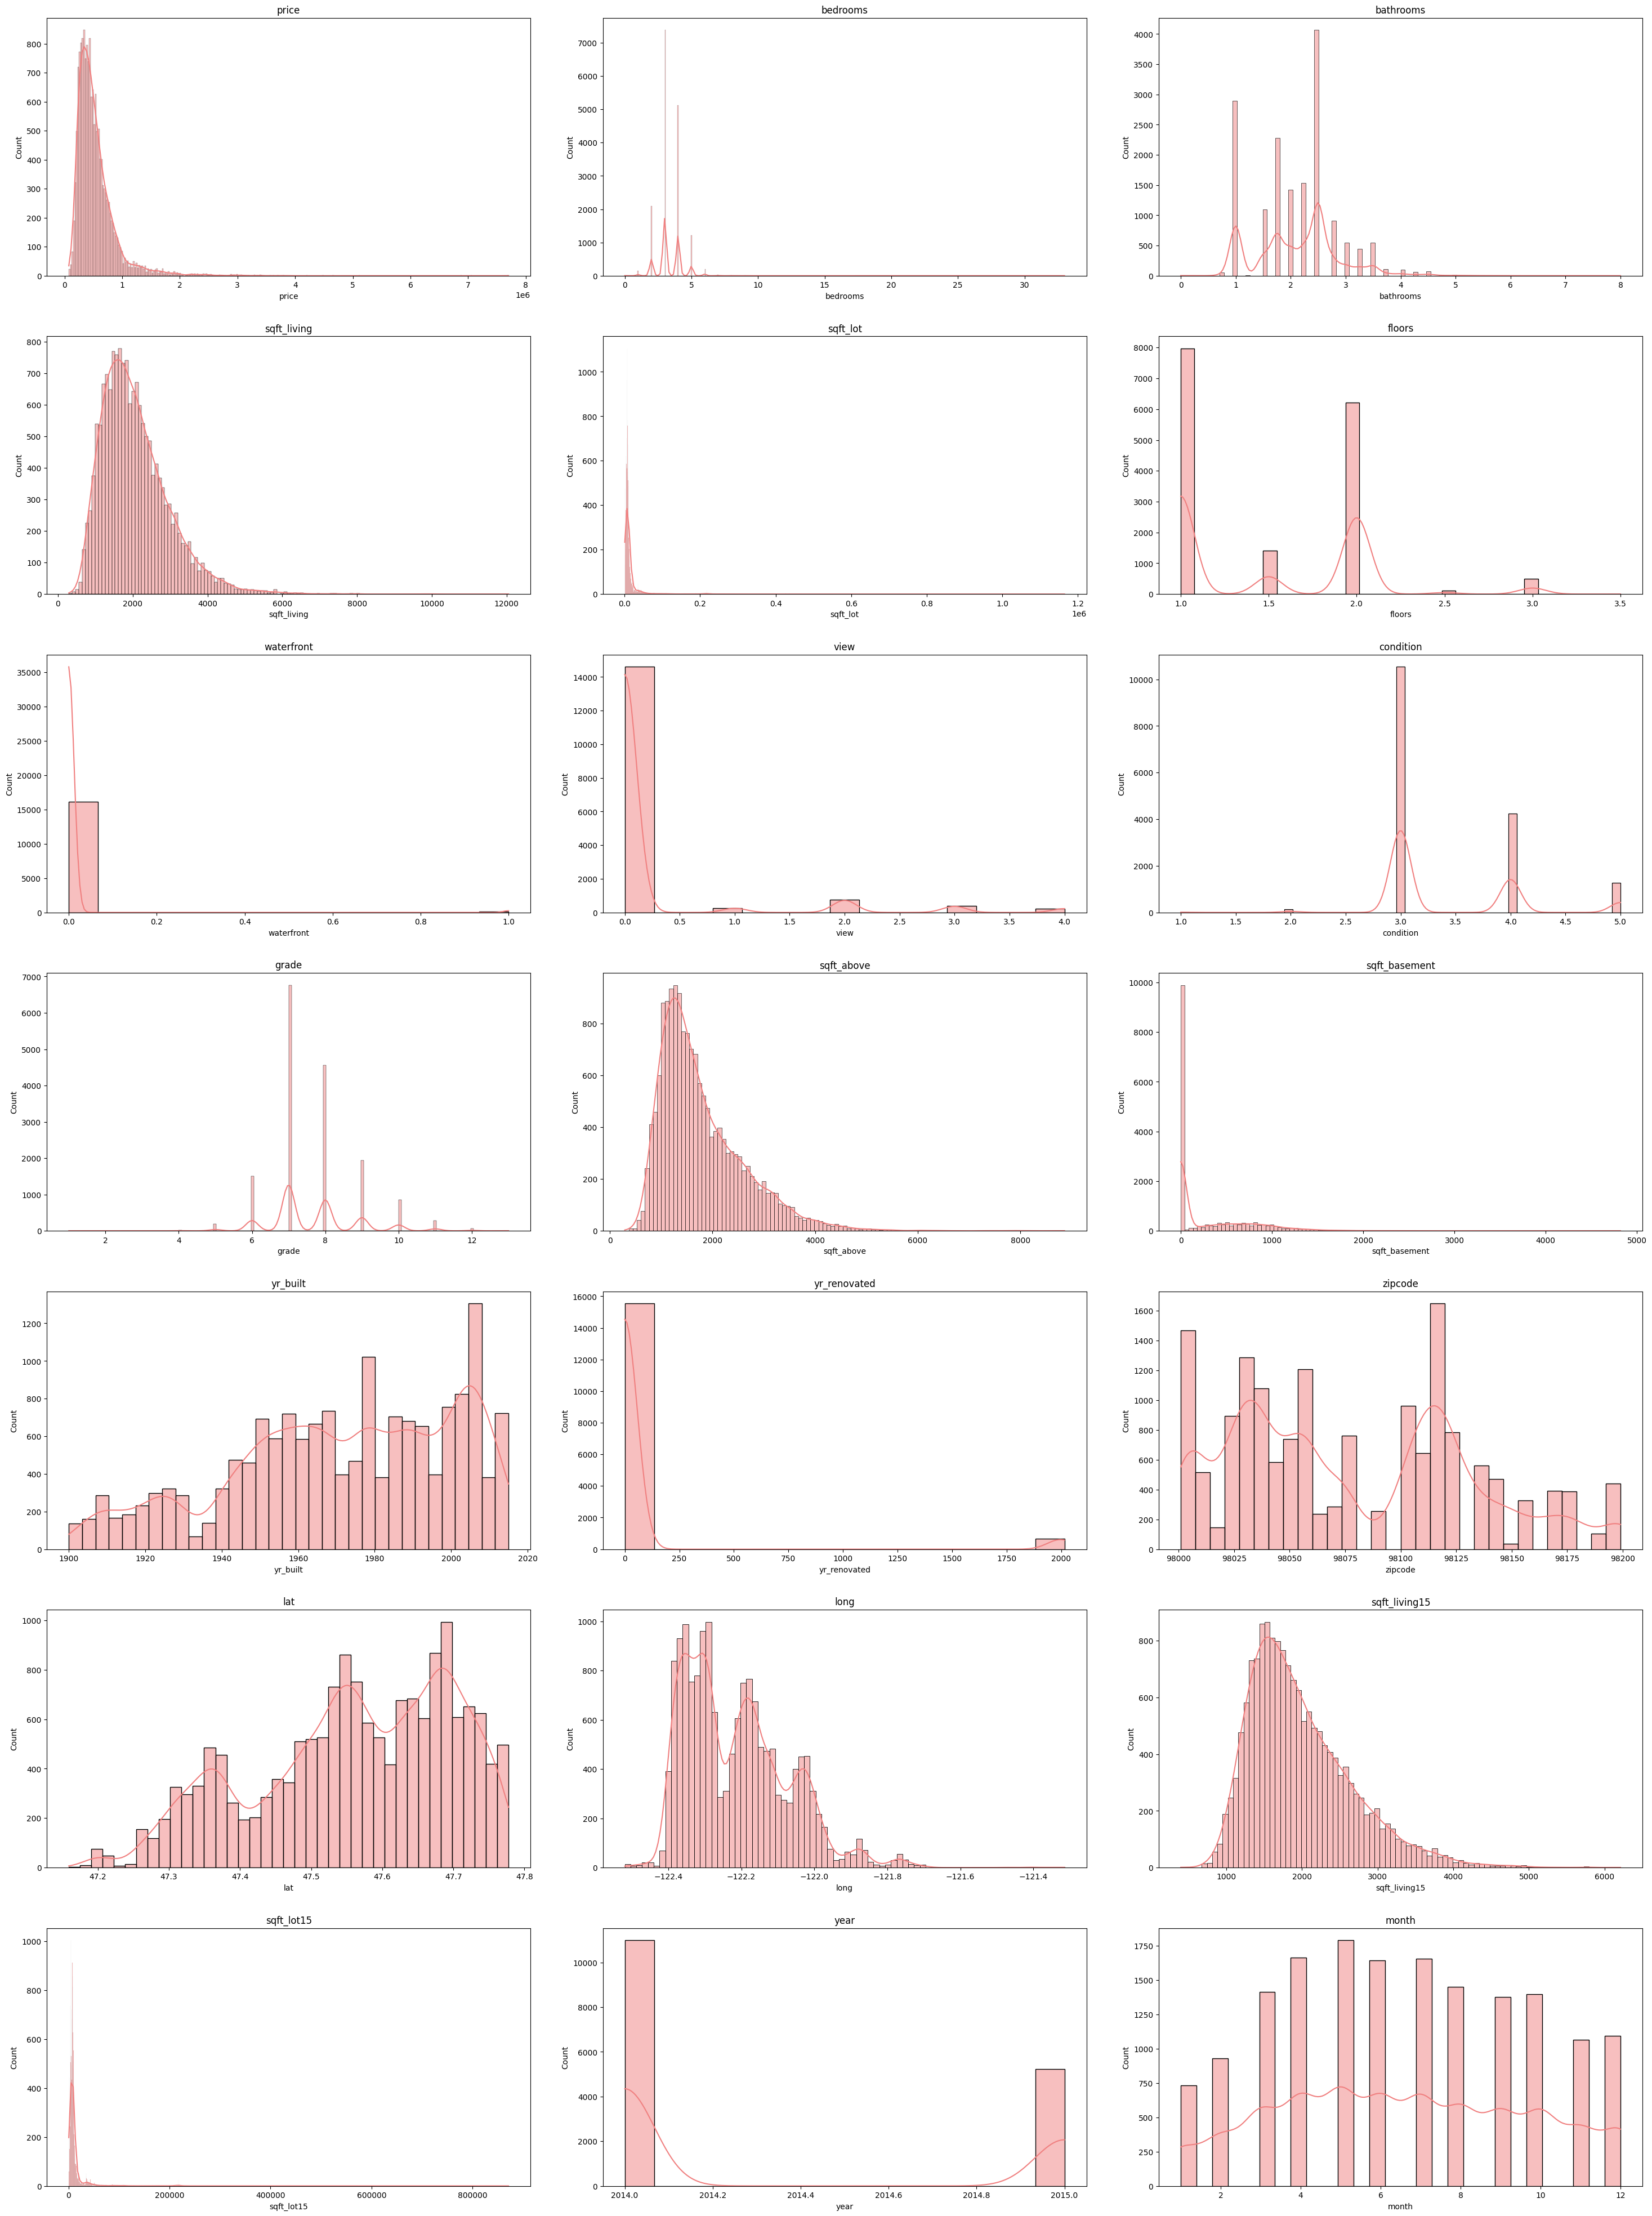

In [14]:
plot_data = df.drop('id', axis=1)
def distributionPlot(dataset):
    """
    This function creates distribution plots for all columns in a dataset.
    """
    n_cols = dataset.shape[1]
    rows = int(np.ceil(n_cols / 3))

    fig = plt.figure(figsize=(30, 40))

    for i in tqdm(range(n_cols), desc='Generating Distribution Plots'):
        ax = fig.add_subplot(rows, 3, i + 1)

        sns.histplot(dataset.iloc[:, i], color="lightcoral", kde=True, ax=ax)
        ax.set_title(dataset.columns[i])

    fig.tight_layout(pad=3.0)
    plt.show()

distributionPlot(plot_data)


sqft_living15, sqft_above, sqft_living, price are right skewed and hence might need log transformation

In [15]:
def pieChartPlotter(dataset, columnName):
    """
    This function will take dataset and column as input and plot pie chart of the distribution within that column.
    """
    values = dataset[columnName].value_counts()
    labels = dataset[columnName].unique()
    pie, ax = plt.subplots(figsize=[10, 6])
    patches, texts, autotexts = ax.pie(
        values, labels=labels, autopct='%1.2f%%',
        shadow=True, pctdistance=1.3,
        explode=[0.05]*dataset[columnName].unique()
    )
    plt.legend(patches, labels, loc="best")
    plt.title(columnName, color='white', fontsize=14)
    plt.setp(texts, color='red', fontsize=10)
    plt.setp(autotexts, size=10, color='black')
    autotexts[1].set_color('black')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

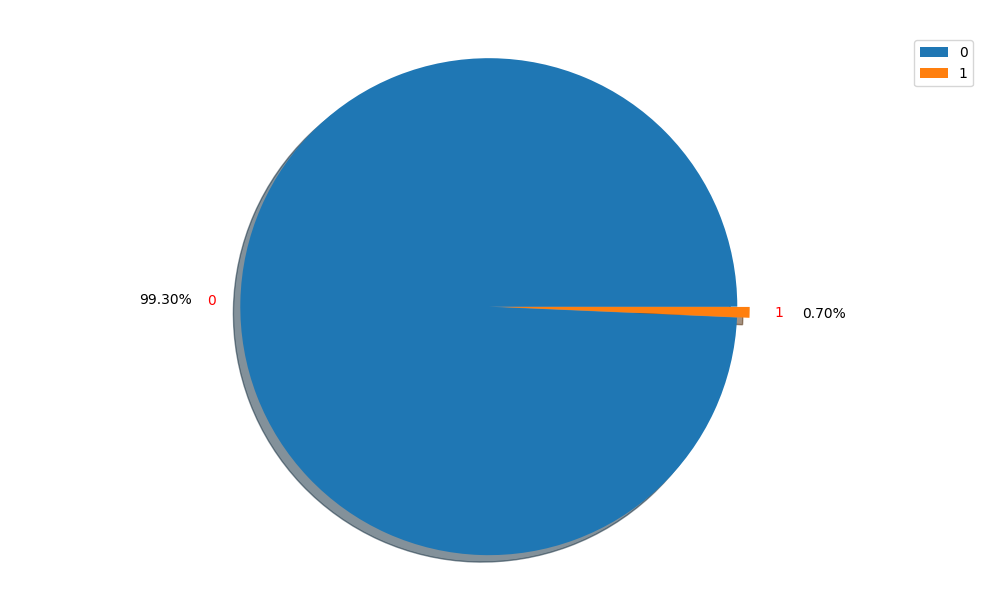

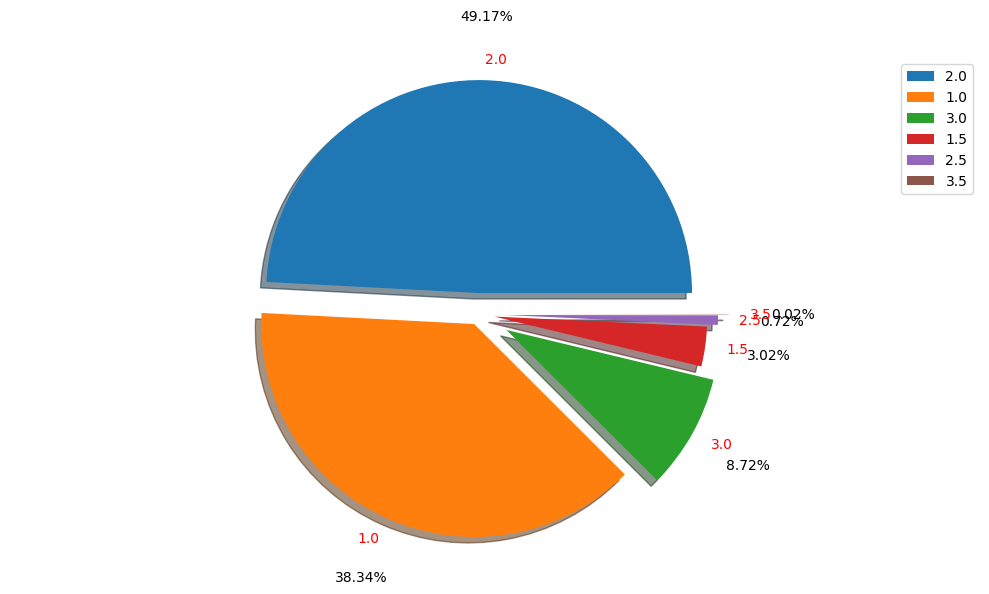

In [16]:
pieChartPlotter(df,'waterfront')
pieChartPlotter(df, 'floors')

Pie Chart show that most of the houses does not have a waterfront and no. of floors are majorily 1 and 2 in the dataset.

In [17]:
def countPlotter(dataset,a,b):
    """
    This function will take dataset and create a countplot for each column except 'price'
    """
    fig = plt.figure(figsize=(a, b))

    cols = [col for col in dataset.columns if col != 'price']
    rows = int(np.ceil(len(cols) / 2))

    plot_idx = 1
    for col in tqdm(cols, desc='Generating Count Plots'):
        ax = fig.add_subplot(rows, 2, plot_idx)

        sns.countplot(
            x=col,
            data=dataset,
            order=dataset[col].value_counts().index,
            ax=ax
        )

        plot_idx += 1

    fig.tight_layout(pad=3.0)
    plt.show()


Generating Count Plots: 100%|██████████| 9/9 [00:00<00:00, 12.67it/s]


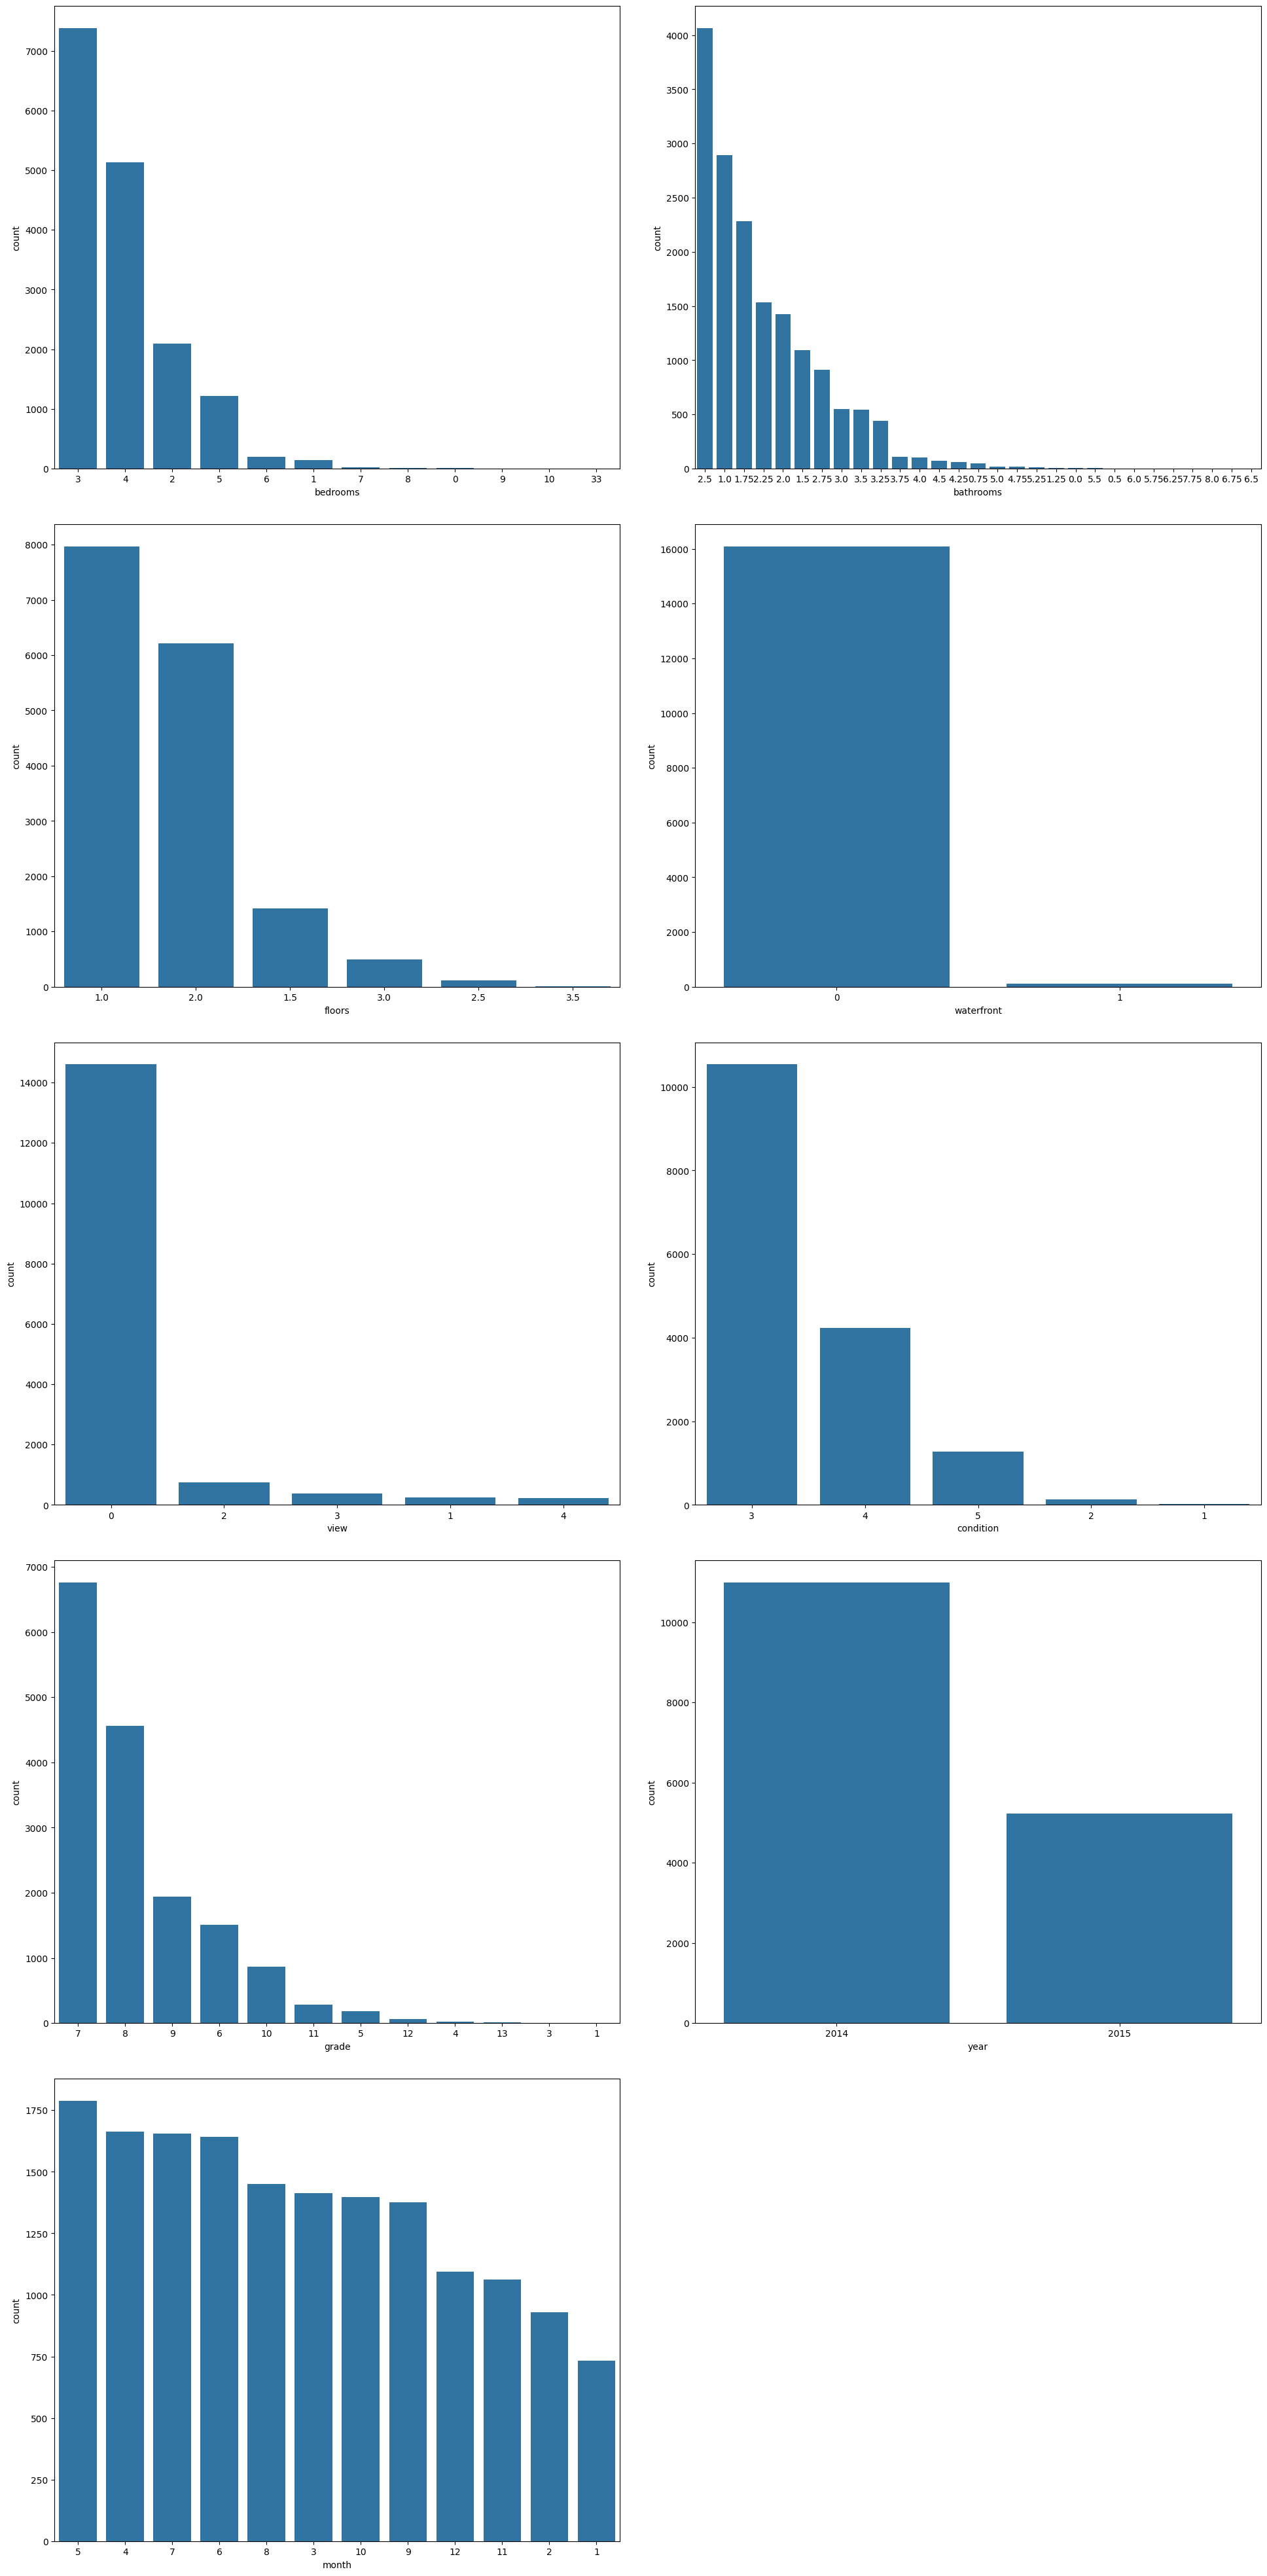

In [18]:
# Dividing data for plotting
plot_data = df.drop(
    ['id', 'sqft_living15', 'sqft_lot15', 'lat', 'long', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode'], axis=1)

countPlotter(plot_data,20,40)

In [19]:
df[df['bedrooms']>7]

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
2803,8823900290,1400000,9,4.00,4620,5508,2.5,0,0,3,...,750,1915,0,98105,47.6684,-122.309,2710,4320,2015,3
3015,685000115,2150000,8,6.00,4340,9415,2.0,0,0,3,...,0,1967,0,98004,47.6316,-122.202,2050,9100,2014,10
3042,8823901445,934000,9,3.00,2820,4480,2.0,0,0,3,...,940,1918,0,98105,47.6654,-122.307,2460,4400,2015,3
3193,2402100895,640000,33,1.75,1620,6000,1.0,0,0,5,...,580,1947,0,98103,47.6878,-122.331,1330,4700,2014,6
3220,1997200215,599999,9,4.50,3830,6988,2.5,0,0,3,...,1380,1938,0,98103,47.6927,-122.338,1460,6291,2014,5
3609,1873400020,340000,8,2.75,2790,6695,1.0,0,0,3,...,1320,1977,0,98133,47.7565,-122.331,1760,7624,2014,7
4030,2769600590,900000,8,4.00,4020,7500,1.0,0,0,3,...,2010,1968,0,98107,47.6732,-122.363,1560,3737,2014,10
5202,9126101740,490000,8,5.00,2800,2580,2.0,0,0,3,...,920,1997,0,98122,47.6086,-122.303,1800,2580,2014,12
5296,1338600225,1970000,8,3.50,4440,6480,2.0,0,3,5,...,1300,1959,0,98112,47.6310,-122.303,4440,8640,2014,5
5777,627300145,1148000,10,5.25,4590,10920,1.0,0,2,3,...,2090,2008,0,98004,47.5861,-122.113,2730,10400,2014,8


Clearly the property having 33 bedroom with so less price sounds unreal and an outlier.

In [20]:
df=df[df.bedrooms<11]

Let's check upon the sqft column and see if we can find some relation.

In [21]:
df[['sqft_lot','sqft_basement','sqft_living','sqft_above']]

,sqft_lot,sqft_basement,sqft_living,sqft_above
0,9240,0,1810,1810
1,2788,0,1600,1600
2,8638,0,1720,1720
3,705,90,1240,1150
4,13356,0,1280,1280
...,...,...,...,...
16204,6914,0,1000,1000
16205,5002,0,3087,3087
16206,4780,0,2120,2120
16207,15000,0,380,380


Since sqft_above+sqft_basement=sqft_living. We will check this condition

In [22]:
df[df['sqft_above']+df['sqft_basement']!=df['sqft_living']]

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month


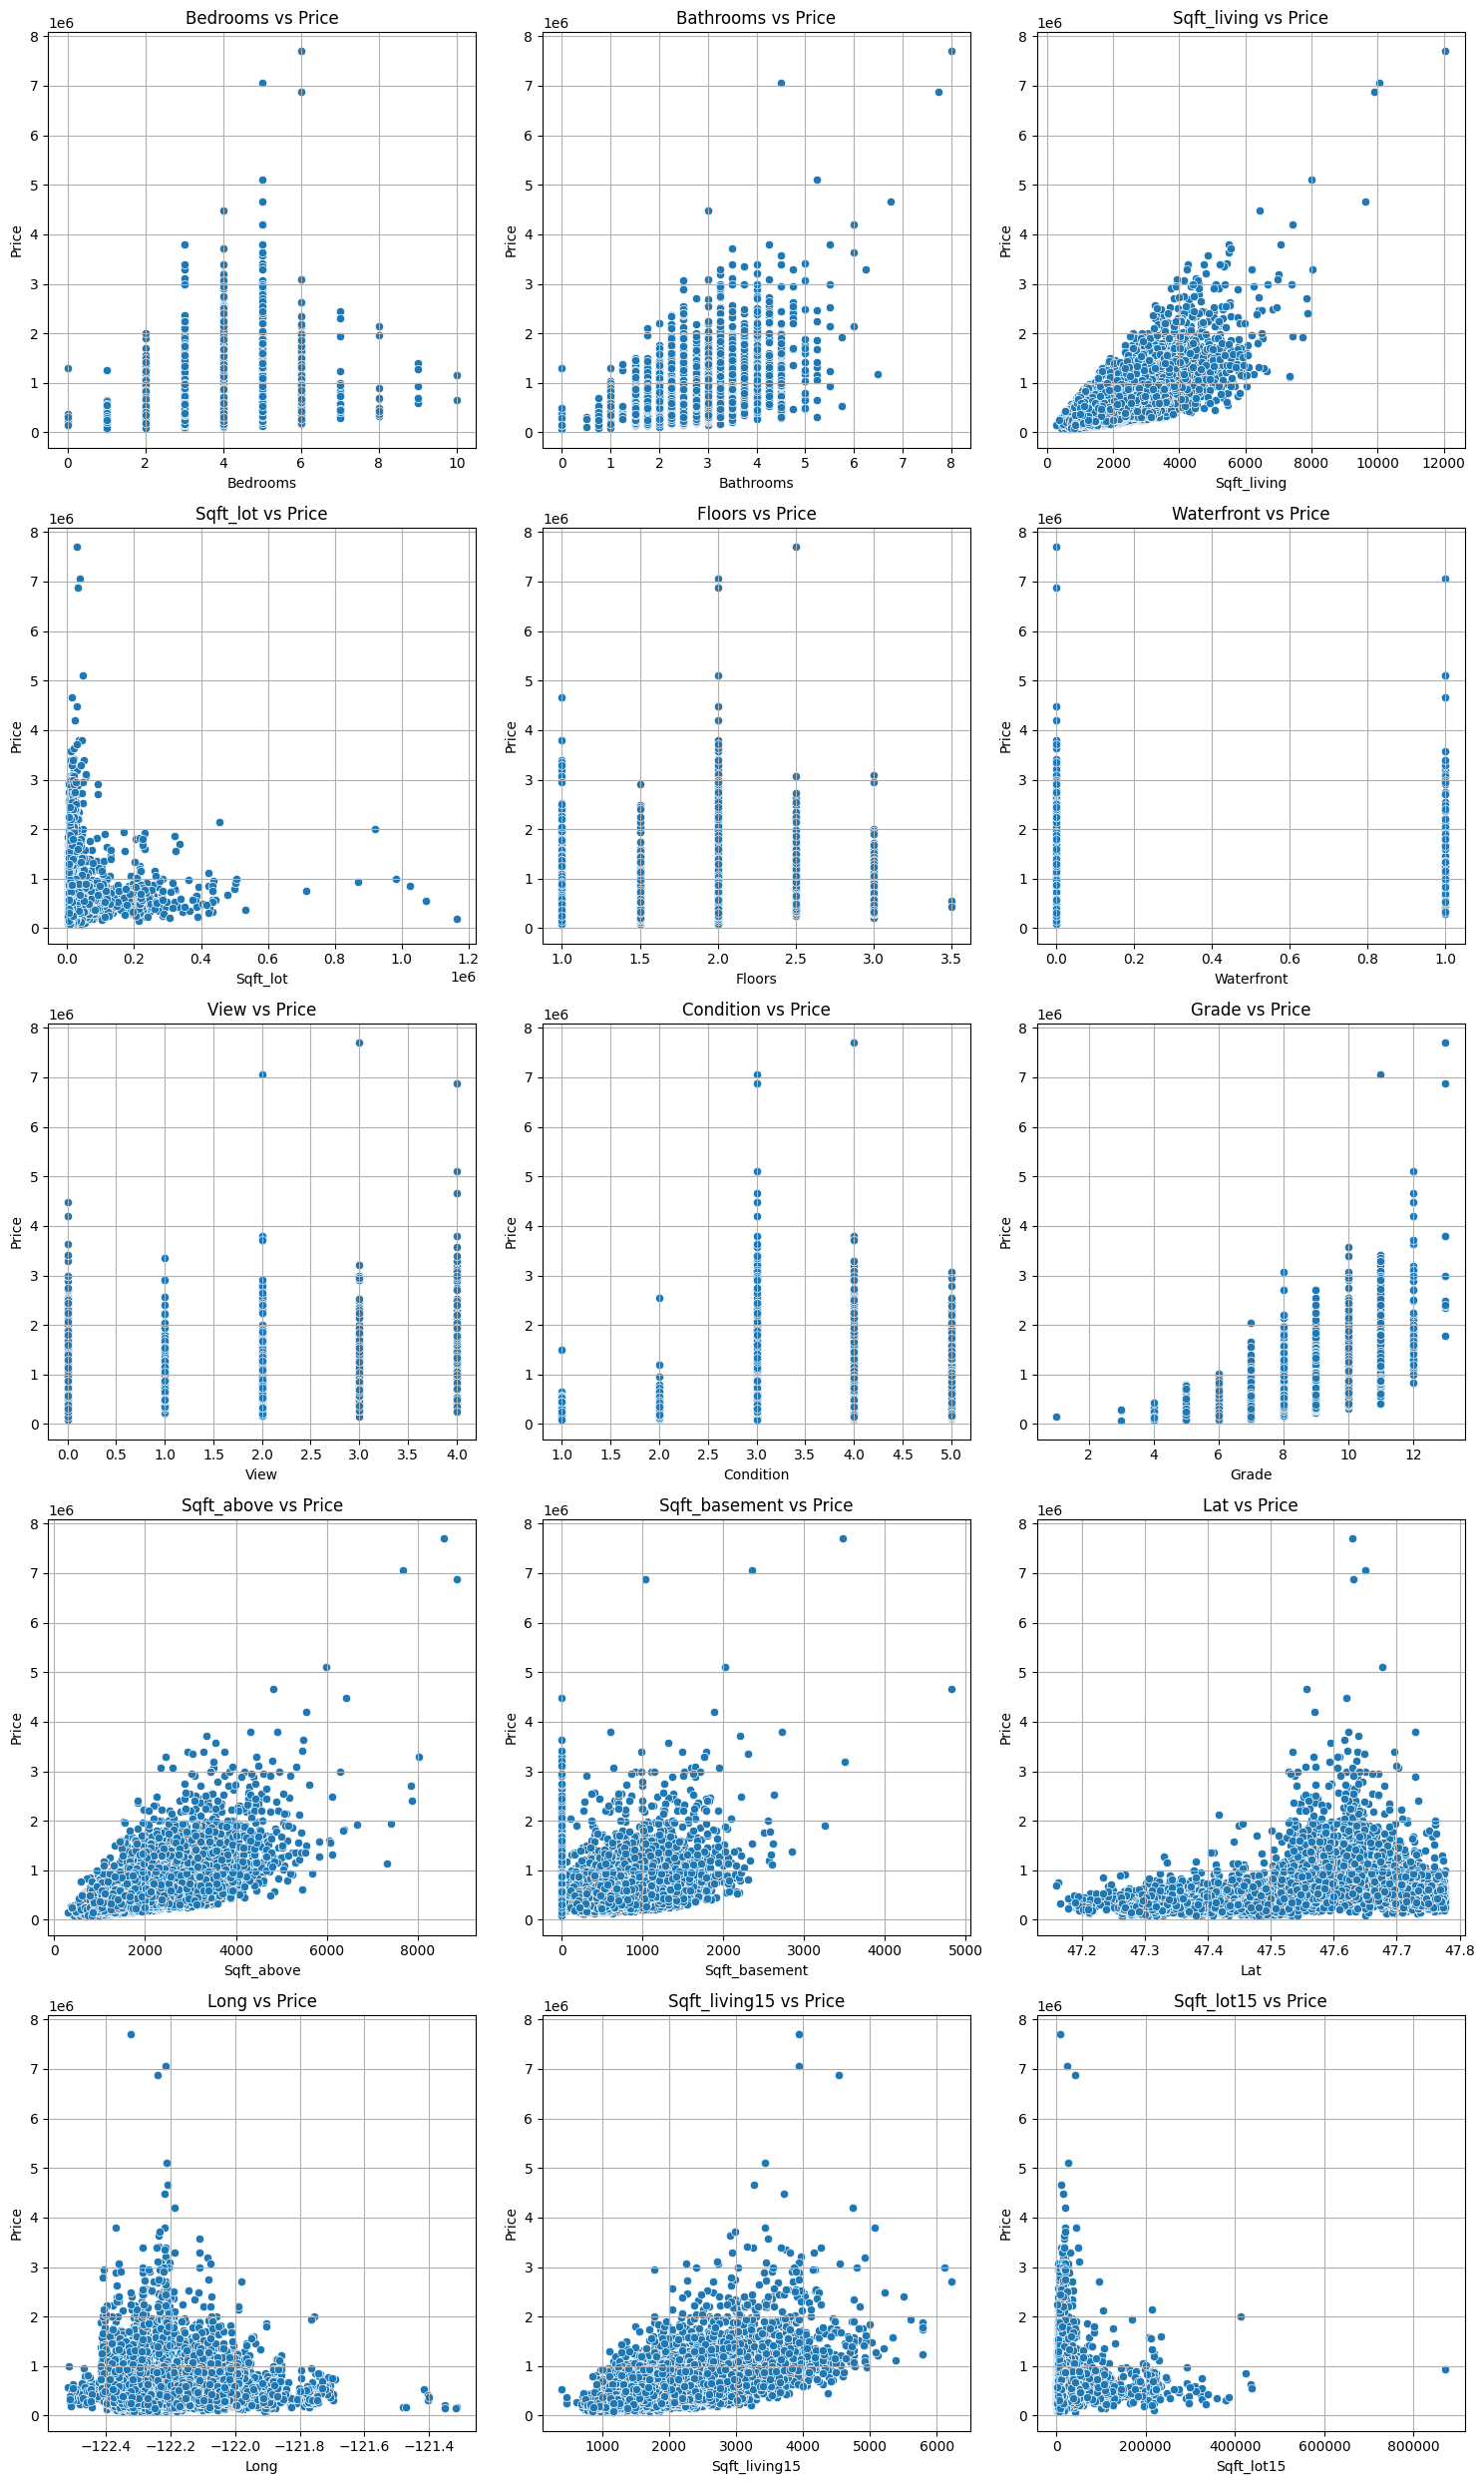

In [23]:
plot_data = df.drop(['id', 'yr_built', 'yr_renovated', 'zipcode','year','month'], axis=1)
def plot_scatter(data):
    target = 'price'
    cols = 3
    features = [col for col in data.columns if col != target]
    rows = int(np.ceil(len(features) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    # Loop through each feature and create scatterplots
    for i, column in enumerate(features):
        sns.scatterplot(x=column, y=target, data=data, ax=axes[i])
        axes[i].set_title(f'{column.capitalize()} vs {target.capitalize()}')
        axes[i].set_xlabel(column.capitalize())
        axes[i].set_ylabel(target.capitalize())
        axes[i].grid(True)


    for i in range(len(data.columns), len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

plot_scatter(plot_data)


Bedrooms - High prices for bedrooms 5-6  
Bathrooms - Kind of increasing relationship  
Sqft_living - Concentrating and increasing with prices  
Sqft_lot - No visible direct relation  
sqft_above and sqft_living15 also have positive relation.

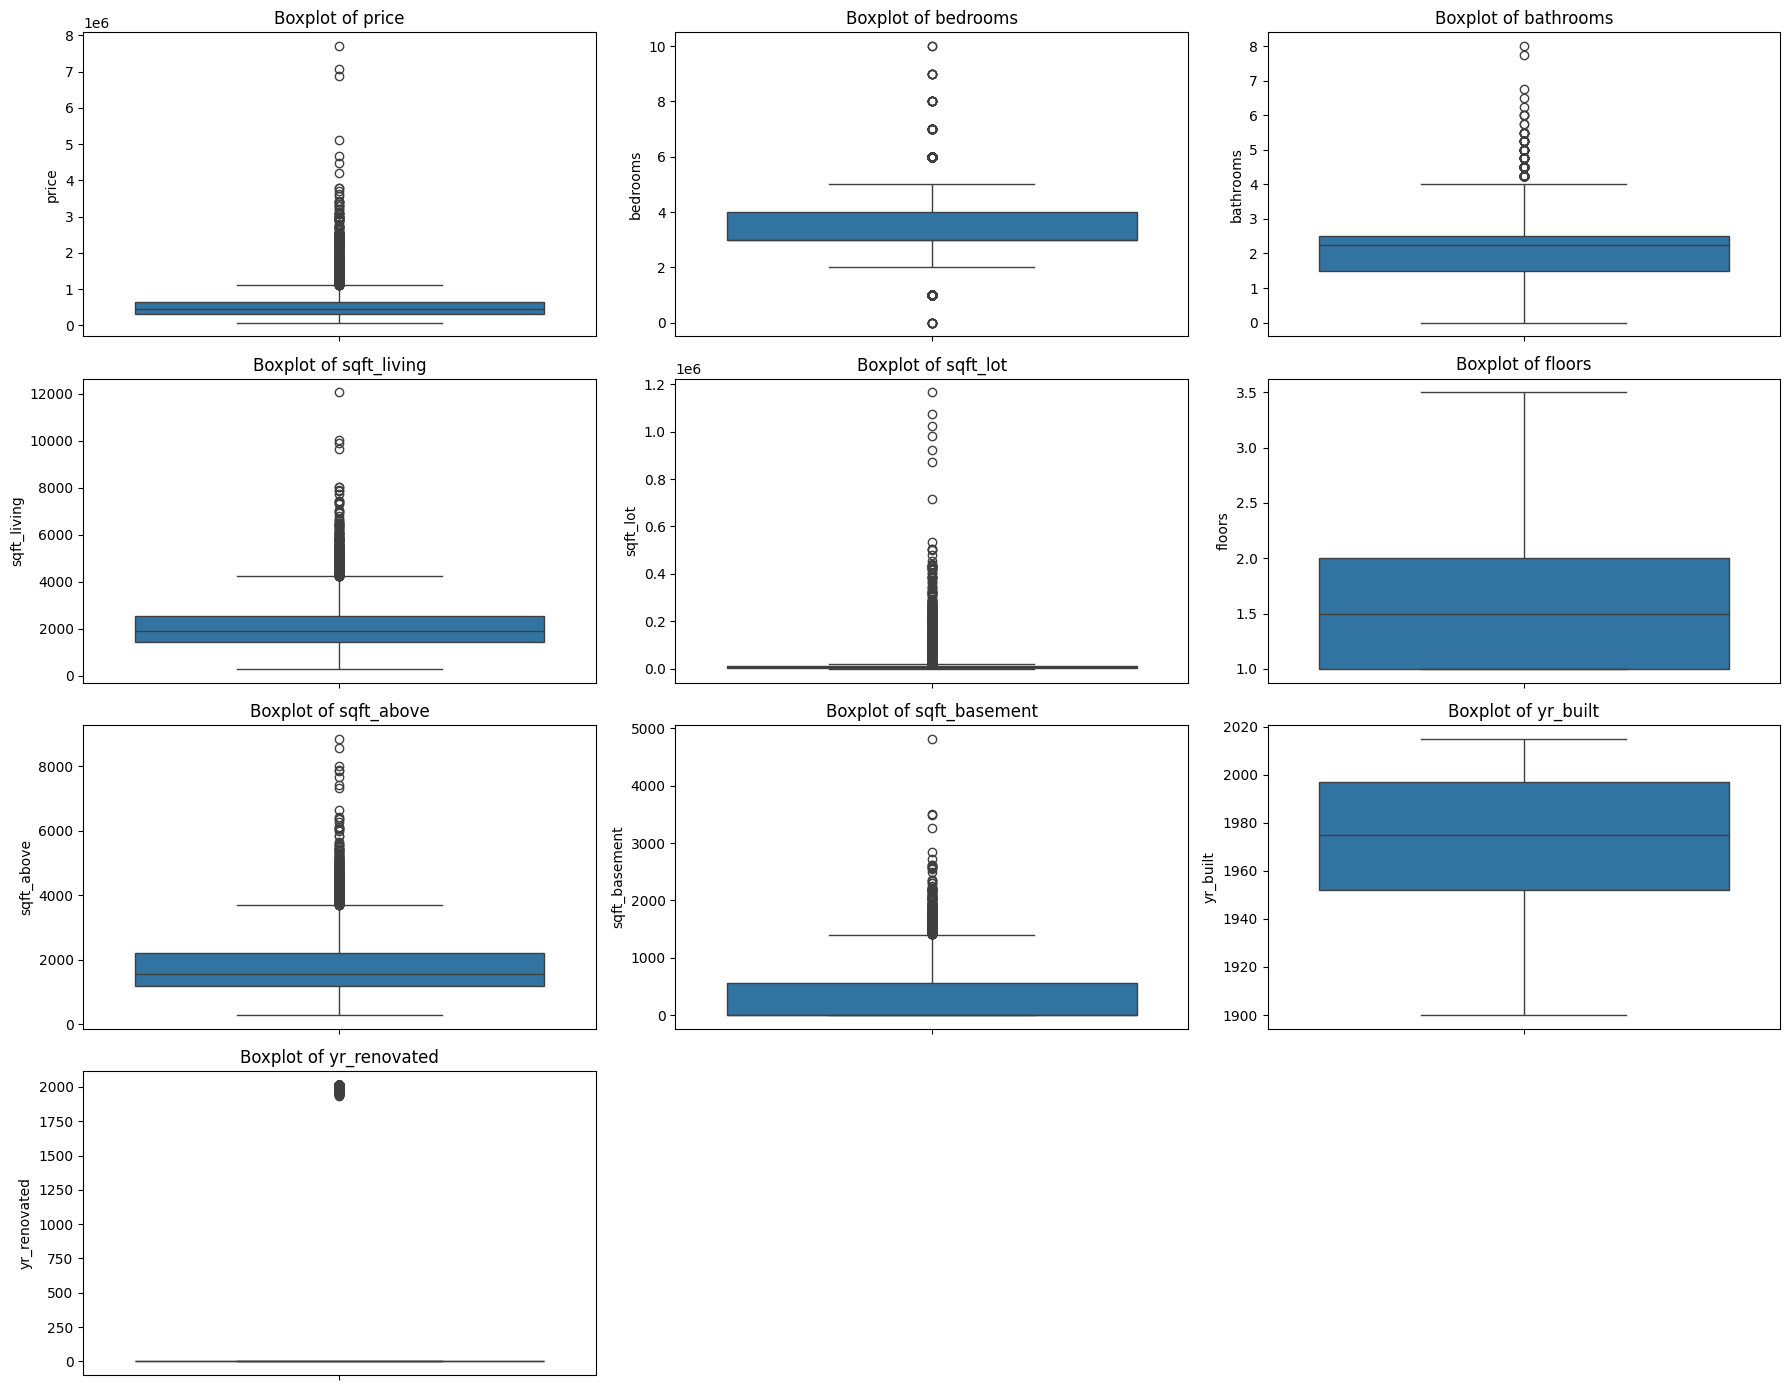

In [24]:
num_cols=['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'sqft_above',
    'sqft_basement', 'yr_built', 'yr_renovated']
plt.figure(figsize=(18, 14))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

We can't find much obvious outliers from the boxplot.
But maybe we can do some better feature engineering

In [25]:
df['log_price'] = np.log(df['price'])
df['house_age'] = 2015 - df['yr_built'] # Since the data is till 2015, we will take that as a reference
df['lat_long_interaction']=df['lat']*df['long']
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)

/tmp/ipython-input-2748124824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_price'] = np.log(df['price'])
/tmp/ipython-input-2748124824.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['house_age'] = 2015 - df['yr_built'] # Since the data is till 2015, we will take that as a reference
/tmp/ipython-input-2748124824.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

Generating Distribution Plots: 100%|██████████| 2/2 [00:00<00:00,  3.83it/s]


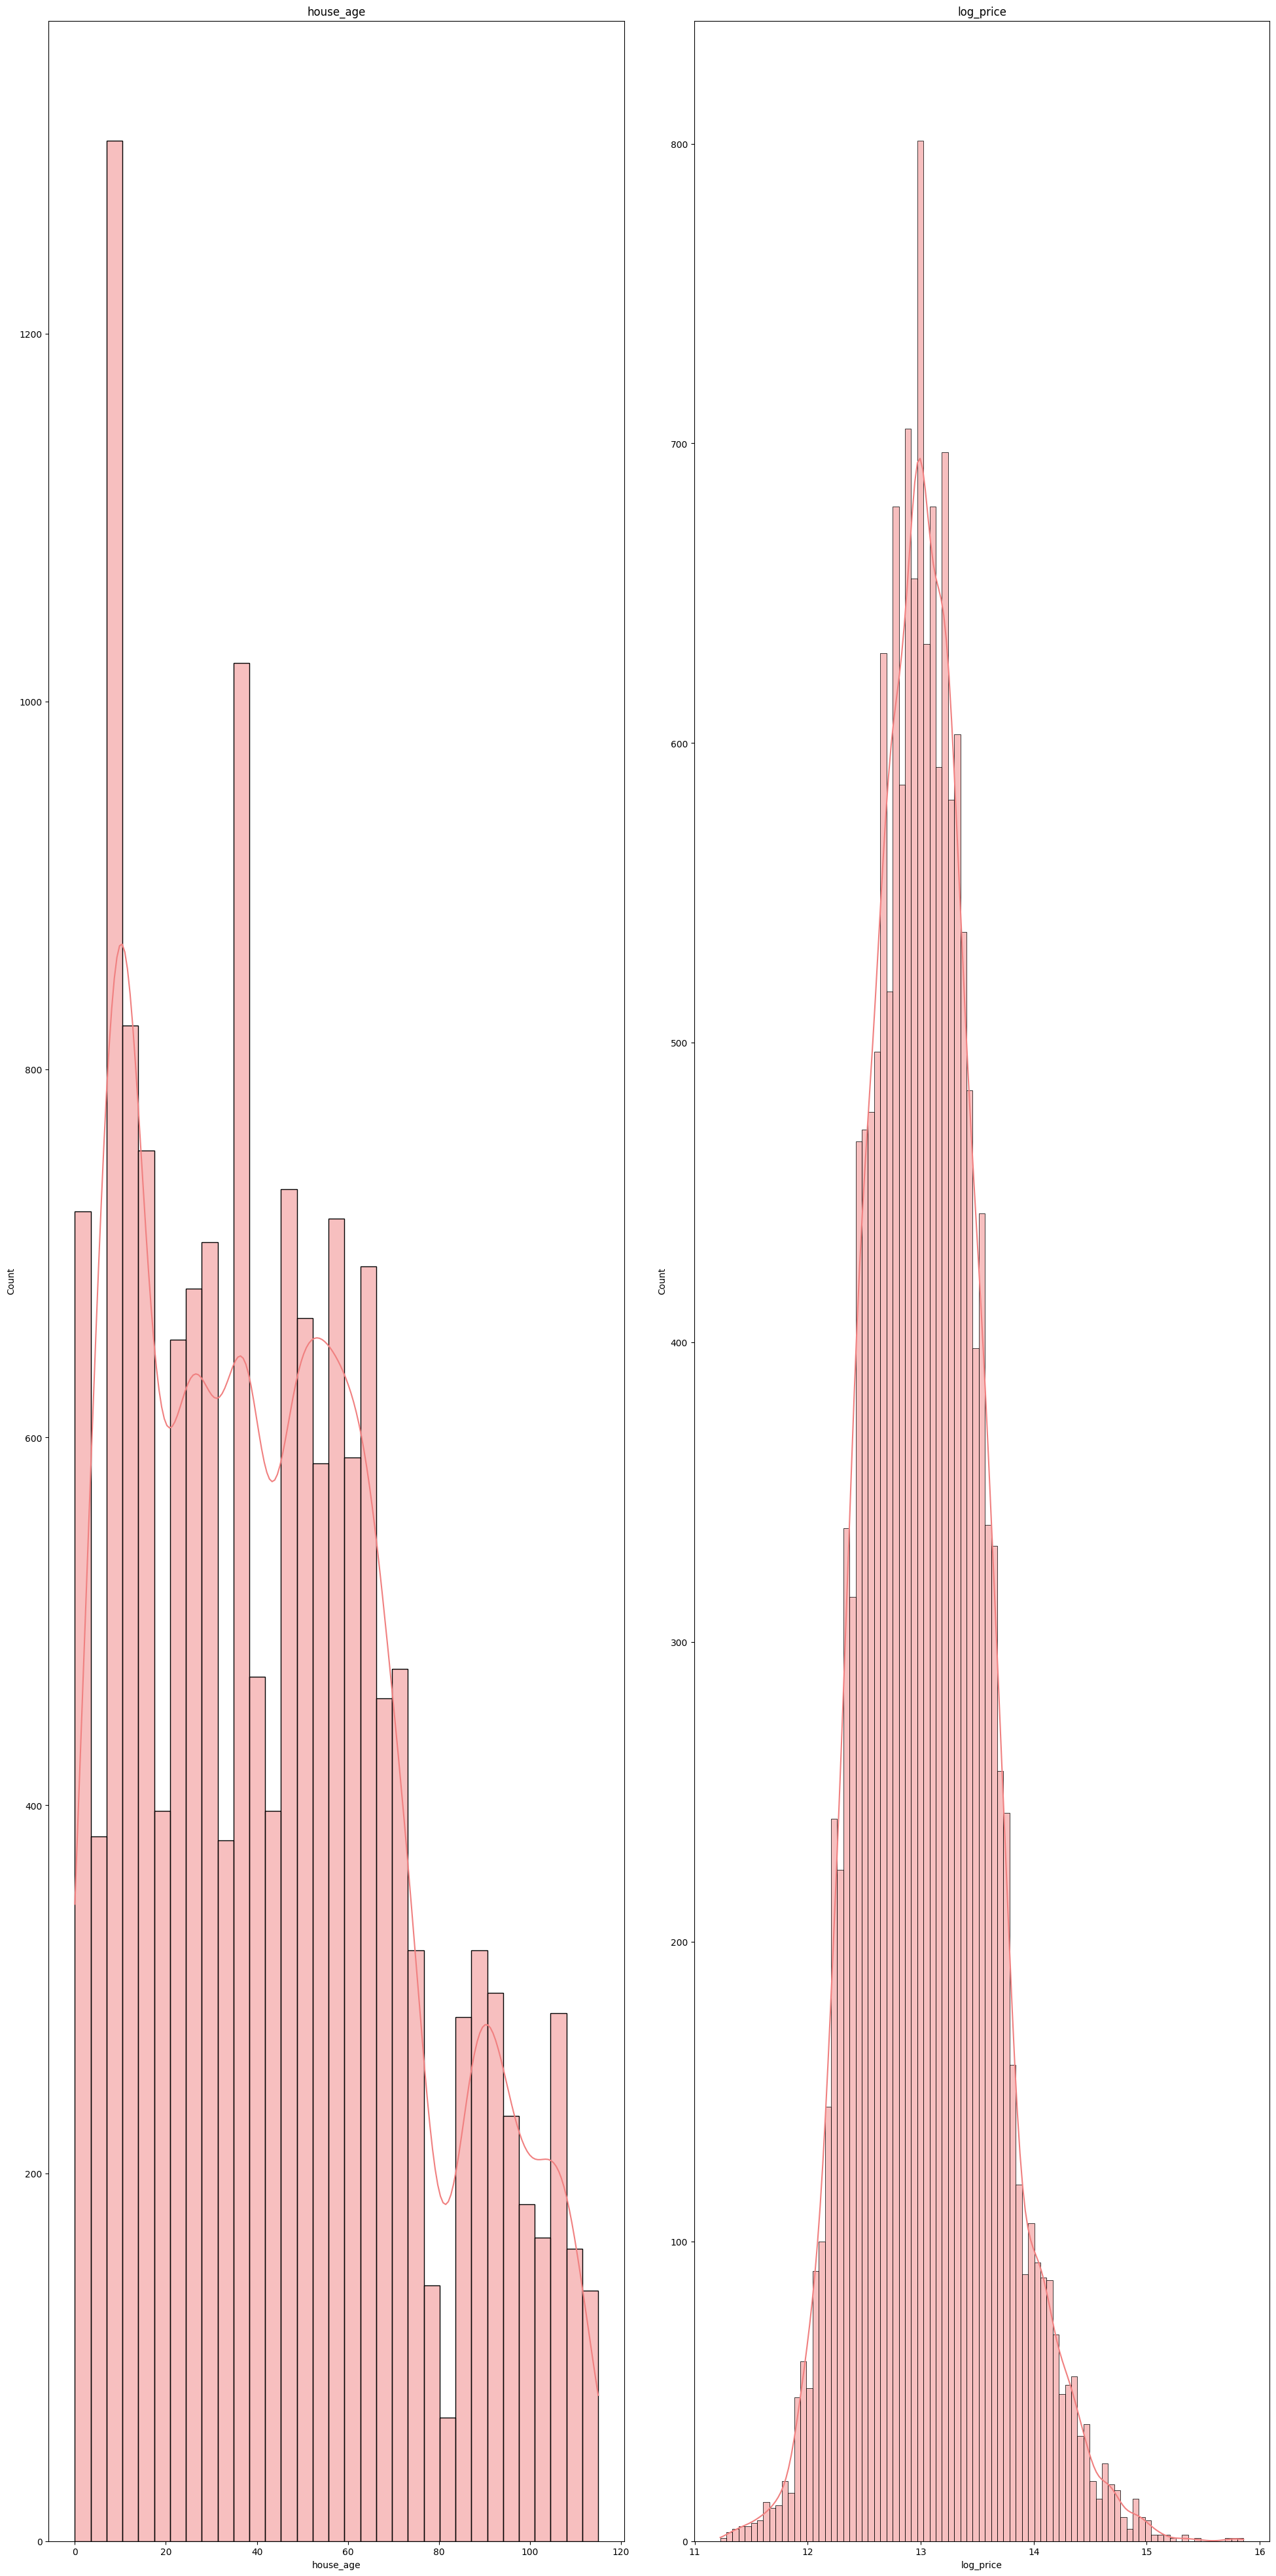

In [26]:
distributionPlot(df[['house_age','log_price']])

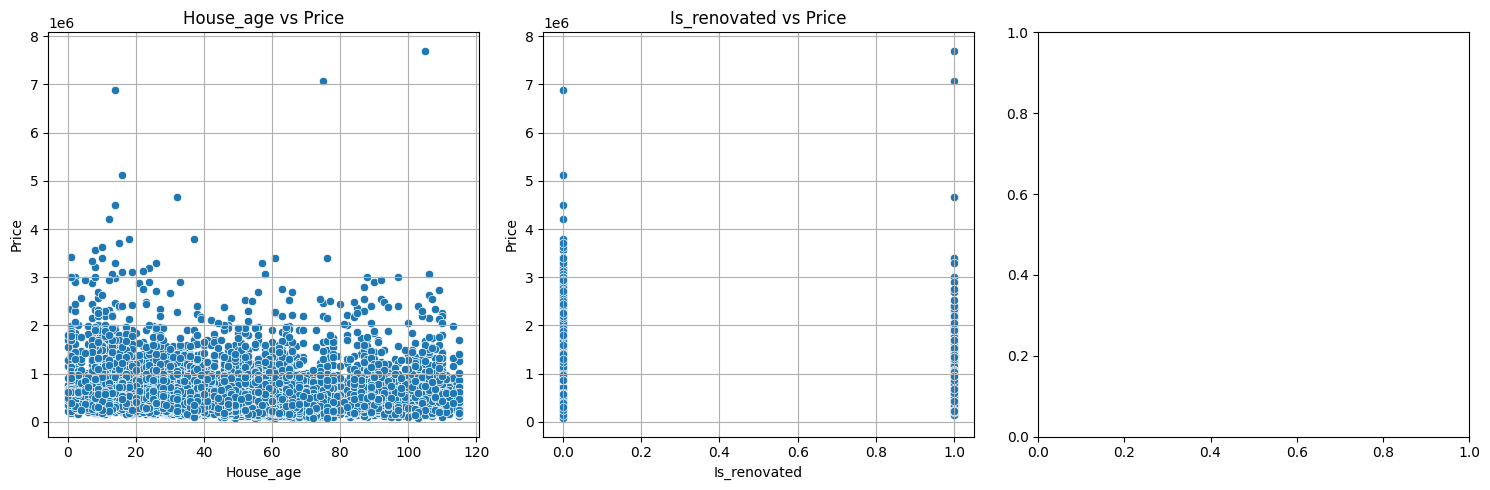

In [27]:
plot_scatter(df[['house_age','price','is_renovated']])

Generating Count Plots: 100%|██████████| 2/2 [00:01<00:00,  1.82it/s]


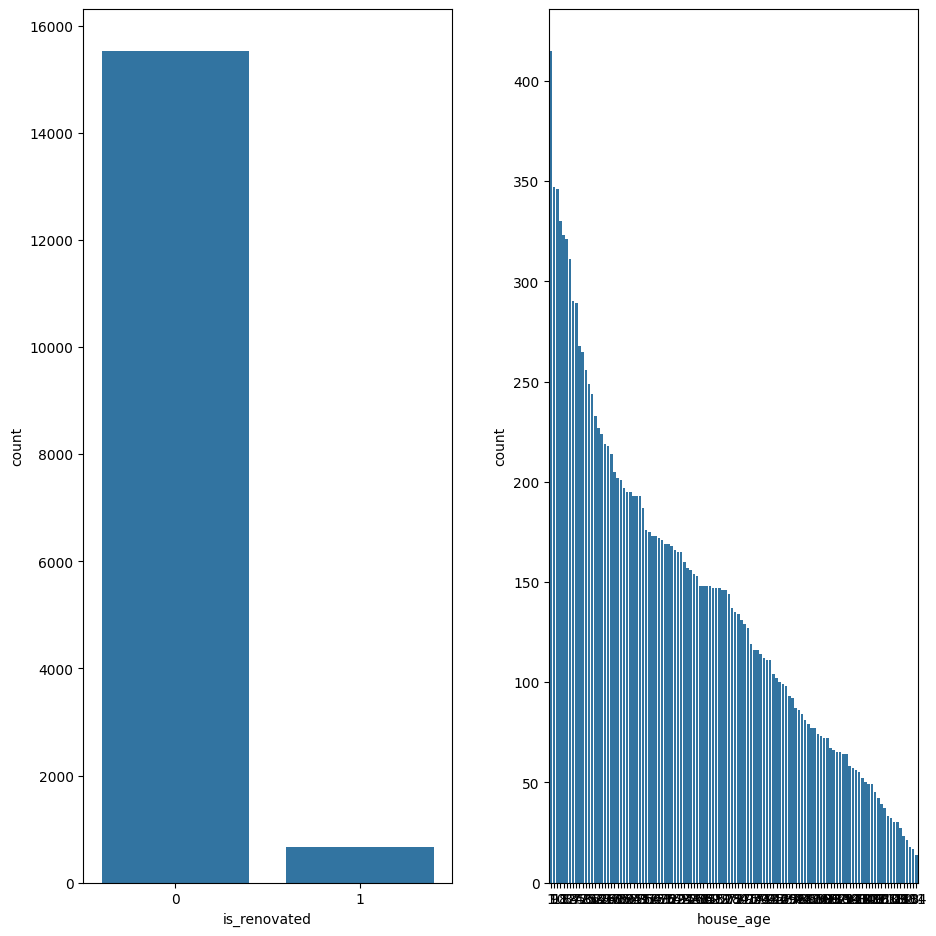

In [28]:
countPlotter(df[['is_renovated','house_age']],10,10)

Most houses are not renovated (nearly 15000)

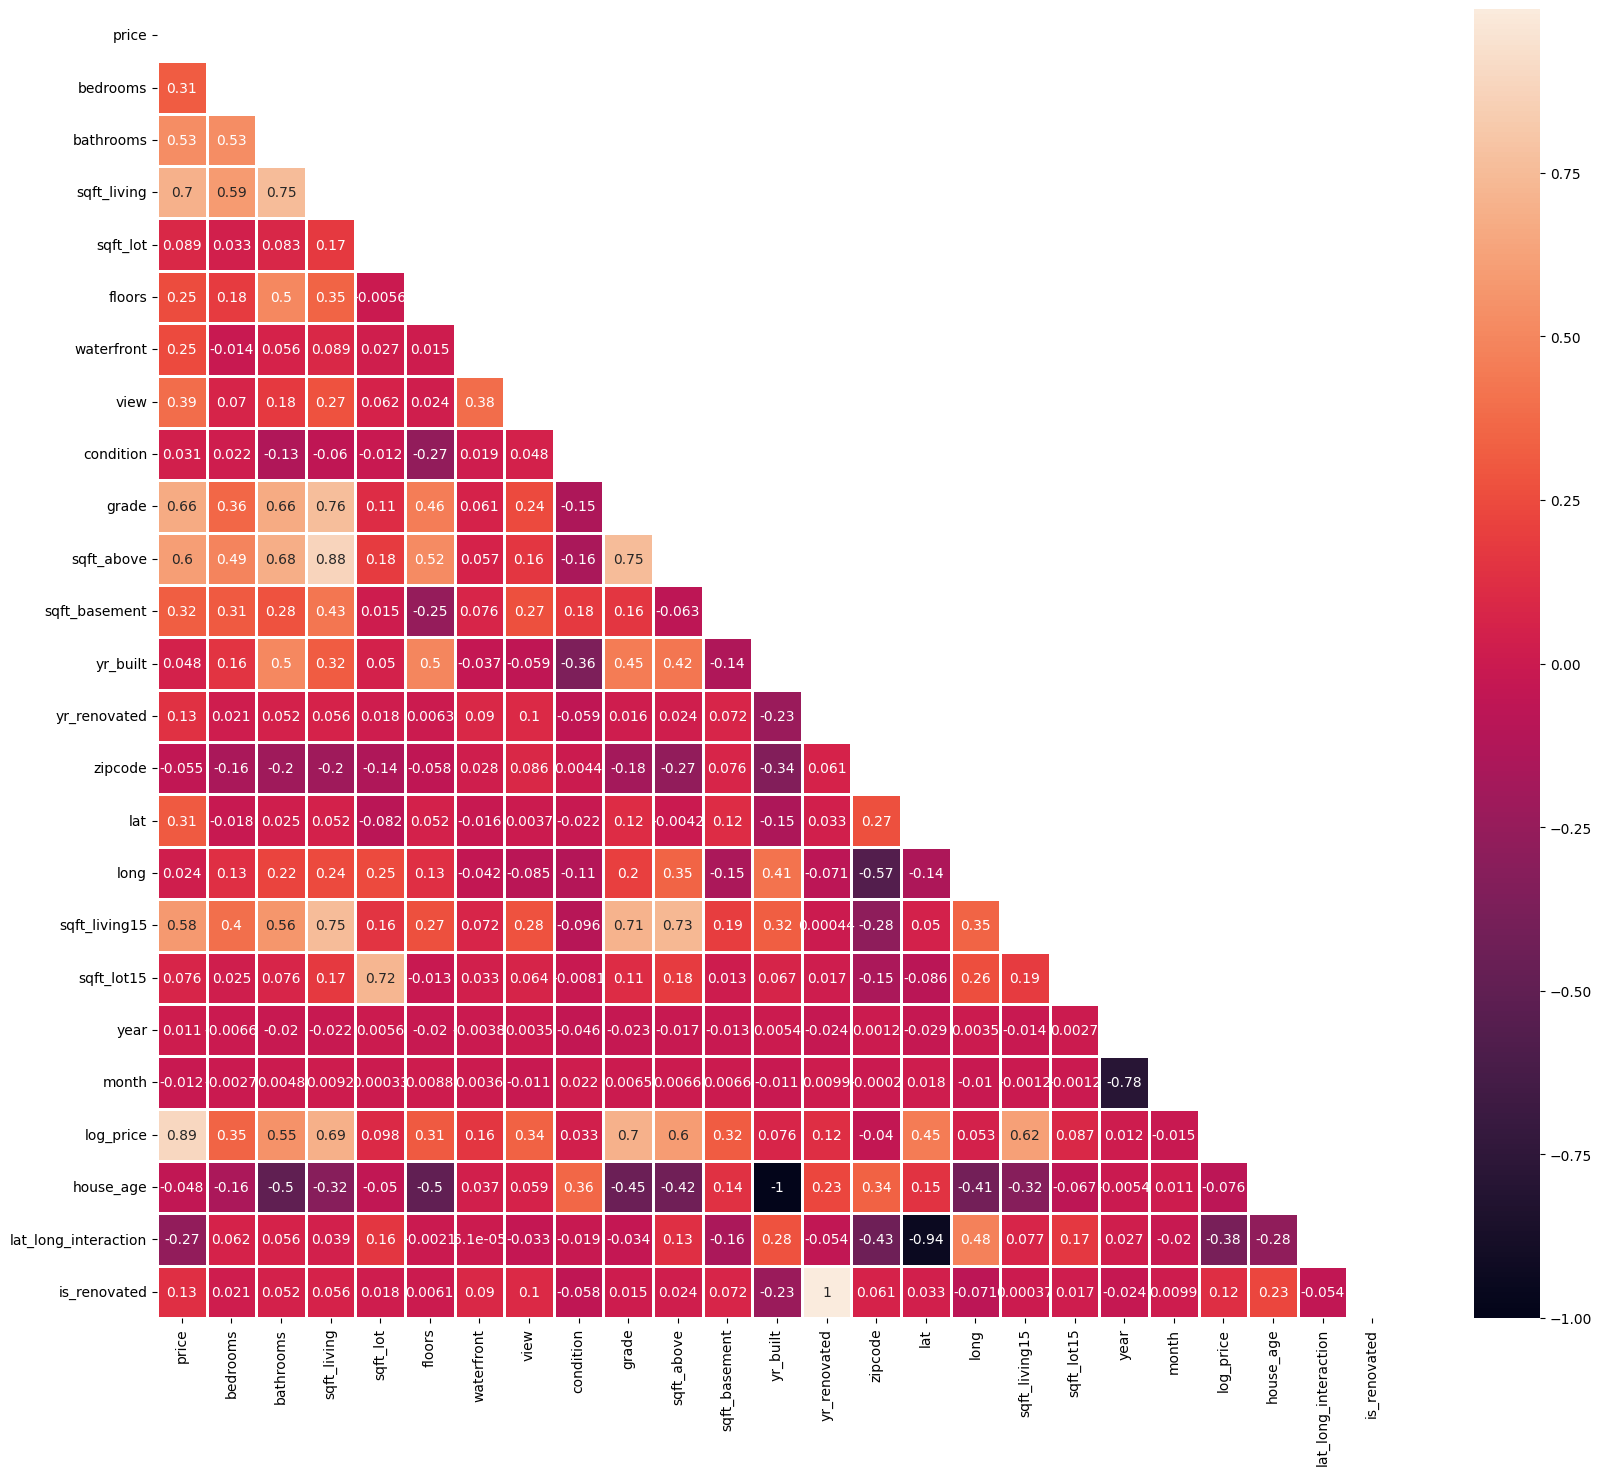

In [29]:
plt.figure(figsize=(20, 17))
matrix = np.triu(df.drop('id',axis=1).corr())
sns.heatmap(df.drop('id',axis=1).corr(), annot=True,
            linewidth=1, mask=matrix, cmap="rocket");

We can also scale down the features which are categorical features and are large in magnitude

In [30]:
df['zipcode']=df['zipcode']-98000
# since all region lies from 98001 to 98199, so we subtract 98k and make the change more efffective

df['year'] = df['year'] - 2014 # since 2014 is minimum value

/tmp/ipython-input-3562190537.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['zipcode']=df['zipcode']-98000
/tmp/ipython-input-3562190537.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = df['year'] - 2014 # since 2014 is minimum value


In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Making a new column of image_paths which are equivalent to my data downloader code

In [34]:
df['image_path']='house_'+df['id'].astype(str)+'.tif'

/tmp/ipython-input-2194956207.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['image_path']='house_'+df['id'].astype(str)+'.tif'


In [35]:
tif_path ='/content/drive/MyDrive/CDC_House/train_naip_images/'+ df['image_path'][1]

with rasterio.open(tif_path) as src:
    image = src.read()
    transform = src.transform
    crs = src.crs

print("Image shape:", image.shape)
print("CRS:", crs)

Image shape: (3, 161, 237)
CRS: EPSG:4326


In [36]:
import random

def show_random_sites(df, tif_path, n=4):
    samples = df.sample(n)

    plt.figure(figsize=(12, 8))

    for i, (_, row) in enumerate(samples.iterrows(), 1):
        with rasterio.open(tif_path+row['image_path']) as src:
            r, c = src.index(row['long'], row['lat'])
            patch = src.read(
                window=((r-32, r+32), (c-32, c+32))
            )

        patch = (patch - patch.min()) / (patch.max() - patch.min())

        plt.subplot(4, n//4, i)
        plt.imshow(patch[:3].transpose(1, 2, 0))
        plt.title(f"Lat: {row['lat']}, Lon: {row['long']}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


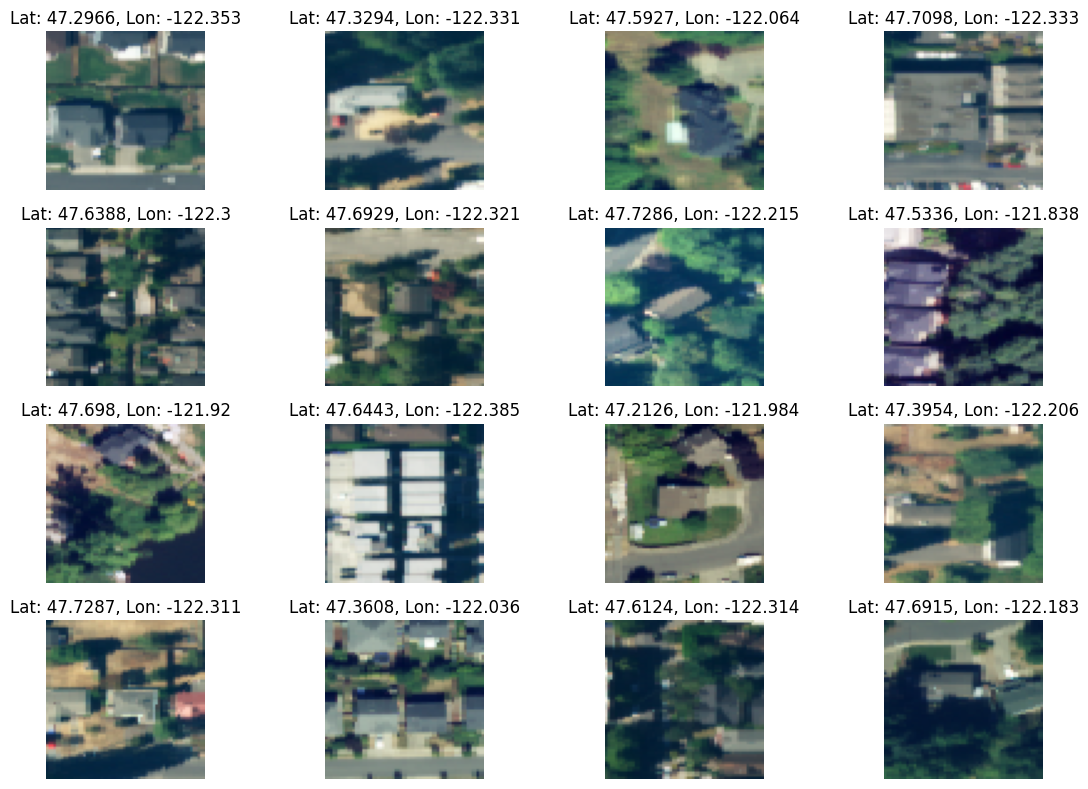

In [37]:
show_random_sites(df,'/content/drive/MyDrive/CDC_House/train_naip_images/', 16)

The satellite images provides the insight of neighbourhood objects such as trees, houses and street level connection.

## 4. Key Takeaways and Modeling Recommendations

### Data Quality Actions

- ⚠️ **Remove outliers**: Bedrooms > 10 (likely data errors)
- 🔧 **Handle skewness**: Log-transform `price`, `sqft_lot`, `sqft_basement`

**End of Exploratory Data Analysis and We process our new train.csv** 

In [38]:
df.to_csv('/content/drive/MyDrive/CDC_House/train_processed.csv',index=False)